In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.metrics import confusion_matrix
import seaborn as sns


df = pd.read_csv("../data/neurosense_cleaned.csv")



In [5]:
X = df.drop(columns=[
    "label",
    "subject",
    "session",
    "trial",
    "sample"
])

y = df["label"]

print("Forma e datasetit origjinal:", df.shape)
print("Forma pas heqjes se kolonave:", X.shape)

Forma e datasetit origjinal: (37575, 346)
Forma pas heqjes se kolonave: (37575, 341)


In [6]:
print("A ekziston ende label ne X?", "label" in X.columns)
print("A ekziston ende subject ne X?", "subject" in X.columns)
print("A ekziston ende session ne X?", "session" in X.columns)
print("A ekziston ende trial ne X?", "trial" in X.columns)
print("A ekziston ende sample ne X?", "sample" in X.columns)

A ekziston ende label ne X? False
A ekziston ende subject ne X? False
A ekziston ende session ne X? False
A ekziston ende trial ne X? False
A ekziston ende sample ne X? False


In [7]:
#K-Means

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Mbushja e vlerave NaN me mesatare
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Normalizimi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Eksperimenti me numrin e grupimeve
results = []

for k in [2, 3, 4, 5, 6, 7, 8]:

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, clusters)

    results.append([k, silhouette])

print("Rezultatet per vlera te ndryshme te k:")

for r in results:
    print(r)

# Eksperimenti me inicializim
print("\nRezultatet per metoda te ndryshme inicializimi:")

for init_method in ["k-means++", "random"]:

    kmeans = KMeans(
        n_clusters=4,
        init=init_method,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, clusters)

    print(init_method, score)

c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\envs\dropout\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:

Rezultatet per vlera te ndryshme te k:
[2, 0.2763462251687234]
[3, 0.19873710029958513]
[4, 0.21939604404967428]
[5, 0.1928704866597244]
[6, 0.20841345724859783]
[7, 0.1835595754389537]
[8, 0.1898545869374559]

Rezultatet per metoda te ndryshme inicializimi:
k-means++ 0.21939604404967428
random 0.17170299284764215


In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(37575, 2)


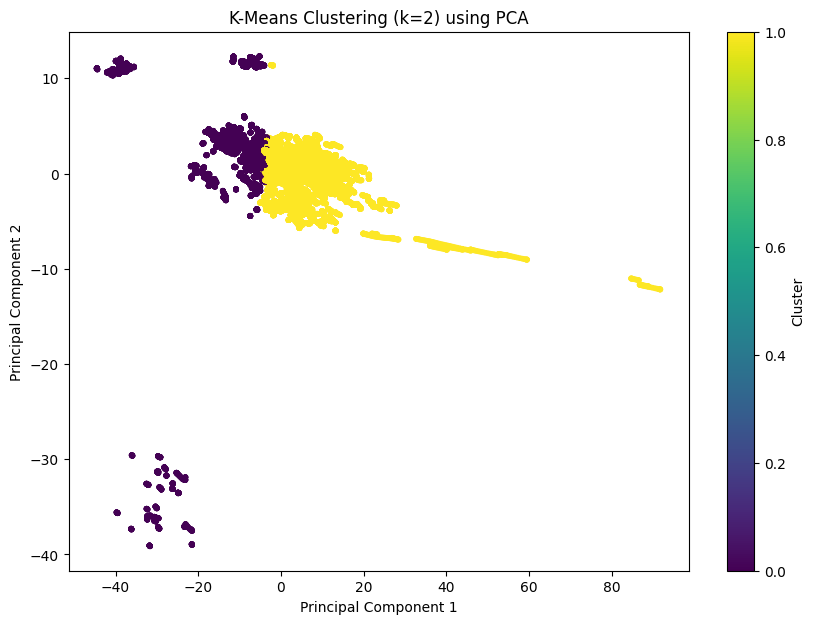

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=10
)

plt.title("K-Means Clustering (k=2) using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()


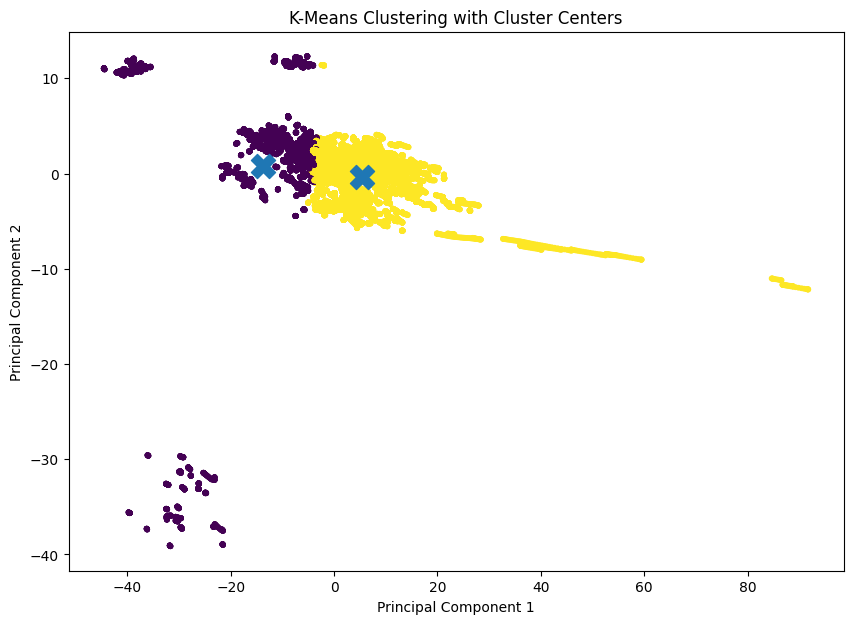

In [10]:
centers = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=10
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker="X",
    s=300
)

plt.title("K-Means Clustering with Cluster Centers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [11]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd

# Krahasimi i cluster-ave te K-Means me etiketat reale
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print("Krahasimi i K-Means me etiketat reale")
print("------------------------------------")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# Tabela e krahasimit: label reale vs cluster
comparison_table = pd.crosstab(
    y,
    clusters,
    rownames=["Etiketa reale"],
    colnames=["Cluster"]
)

print("\nTabela e krahasimit mes etiketave reale dhe cluster-ave:")
print(comparison_table)

Krahasimi i K-Means me etiketat reale
------------------------------------
Adjusted Rand Index (ARI): 0.0001
Normalized Mutual Information (NMI): 0.0003

Tabela e krahasimit mes etiketave reale dhe cluster-ave:
Cluster           0     1
Etiketa reale            
0              2663  7087
1              2576  6949
2              2911  6824
3              2374  6191


In [12]:
from sklearn.preprocessing import StandardScaler

# Hiq kolonat që nuk janë feature
X = df.drop(columns=["label"])

y = df["label"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

eps=2
Clusters: 37
Noise: 4603
----------------
eps=3
Clusters: 54
Noise: 4398
----------------
eps=4
Clusters: 83
Noise: 3672
----------------
eps=5
Clusters: 87
Noise: 2217
----------------
Cluster -1: 3672
Cluster 0: 22
Cluster 1: 31
Cluster 2: 15
Cluster 3: 24
Cluster 4: 10
Cluster 5: 11
Cluster 6: 41
Cluster 7: 11
Cluster 8: 17
Cluster 9: 53
Cluster 10: 13
Cluster 11: 12
Cluster 12: 24
Cluster 13: 13
Cluster 14: 13
Cluster 15: 25
Cluster 16: 10
Cluster 17: 11
Cluster 18: 10
Cluster 19: 11
Cluster 20: 59
Cluster 21: 45
Cluster 22: 10
Cluster 23: 20
Cluster 24: 10
Cluster 25: 10
Cluster 26: 18
Cluster 27: 12
Cluster 28: 10
Cluster 29: 10
Cluster 30: 27
Cluster 31: 11
Cluster 32: 42
Cluster 33: 11
Cluster 34: 10
Cluster 35: 10
Cluster 36: 11
Cluster 37: 16
Cluster 38: 10
Cluster 39: 12
Cluster 40: 22
Cluster 41: 12
Cluster 42: 10
Cluster 43: 11
Cluster 44: 10
Cluster 45: 10
Cluster 46: 22
Cluster 47: 11
Cluster 48: 23
Cluster 49: 17
Cluster 50: 13
Cluster 51: 13
Cluster 52: 12
Cluste

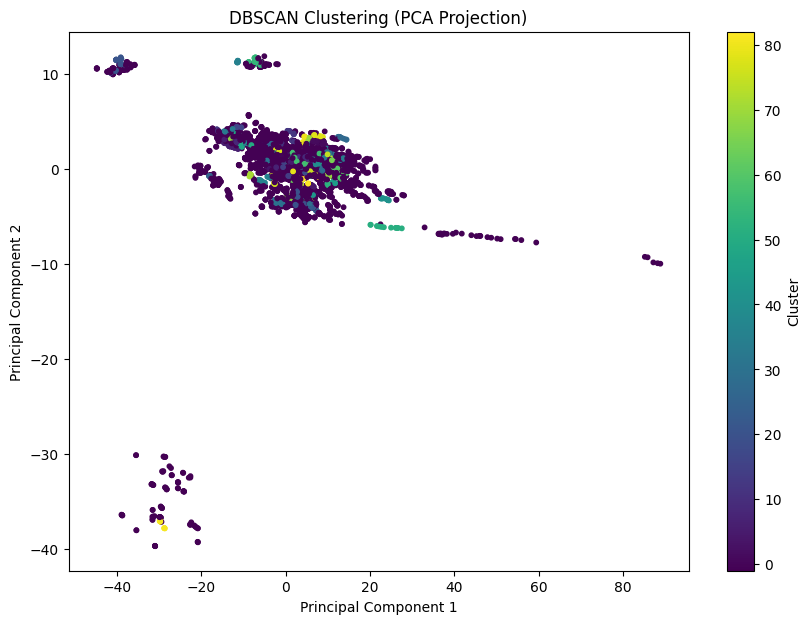

In [ ]:

from sklearn.utils import shuffle
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA



# 1. Ndarja X dhe y
X = df.drop(columns=["label"])
y = df["label"]

# 2. Marrim vetëm kolonat numerike
X = X.select_dtypes(include=[np.number])

# 3. Mbushim NaN me mesataren e kolonës
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# 4. Standardizimi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 5. Shuffle + subset për DBSCAN
X_shuffled, y_shuffled = shuffle(
    X_scaled,
    y,
    random_state=42
)

X_dbscan = X_shuffled[:5000]
y_dbscan = y_shuffled[:5000]

# 6. DBSCAN me disa eps
for eps_value in [2, 3, 4, 5]:

    dbscan = DBSCAN(
        eps=eps_value,
        min_samples=10
    )

    clusters = dbscan.fit_predict(X_dbscan)

    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = np.sum(clusters == -1)

    print(f"eps={eps_value}")
    print("Clusters:", n_clusters)
    print("Noise:", n_noise)
    print("----------------")

# 7. Ruajmë një model final për vizualizim
dbscan_final = DBSCAN(
    eps=4,
    min_samples=10
)

clusters_dbscan = dbscan_final.fit_predict(X_dbscan)

# 8. Shfaqim madhësinë e çdo clusteri
unique, counts = np.unique(clusters_dbscan, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count}")

# 9. PCA për vizualizim 2D
pca = PCA(n_components=2)
X_dbscan_pca = pca.fit_transform(X_dbscan)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_dbscan_pca[:, 0],
    X_dbscan_pca[:, 1],
    c=clusters_dbscan,
    cmap="viridis",
    s=10
)

plt.title("DBSCAN Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()
# 1. Ndarja X dhe y
X = df.drop(columns=["label"])
y = df["label"]

# 2. Marrim vetëm kolonat numerike
X = X.select_dtypes(include=[np.number])





In [19]:
# 3. Mbushim NaN me mesataren e kolonës
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# 4. Standardizimi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 5. Shuffle + subset për DBSCAN
X_shuffled, y_shuffled = shuffle(
    X_scaled,
    y,
    random_state=42
)

X_dbscan = X_shuffled[:5000]
y_dbscan = y_shuffled[:5000]

eps=2
Clusters: 37
Noise: 4603
----------------
eps=3
Clusters: 54
Noise: 4398
----------------
eps=4
Clusters: 83
Noise: 3672
----------------
eps=5
Clusters: 87
Noise: 2217
----------------
Cluster -1: 3672
Cluster 0: 22
Cluster 1: 31
Cluster 2: 15
Cluster 3: 24
Cluster 4: 10
Cluster 5: 11
Cluster 6: 41
Cluster 7: 11
Cluster 8: 17
Cluster 9: 53
Cluster 10: 13
Cluster 11: 12
Cluster 12: 24
Cluster 13: 13
Cluster 14: 13
Cluster 15: 25
Cluster 16: 10
Cluster 17: 11
Cluster 18: 10
Cluster 19: 11
Cluster 20: 59
Cluster 21: 45
Cluster 22: 10
Cluster 23: 20
Cluster 24: 10
Cluster 25: 10
Cluster 26: 18
Cluster 27: 12
Cluster 28: 10
Cluster 29: 10
Cluster 30: 27
Cluster 31: 11
Cluster 32: 42
Cluster 33: 11
Cluster 34: 10
Cluster 35: 10
Cluster 36: 11
Cluster 37: 16
Cluster 38: 10
Cluster 39: 12
Cluster 40: 22
Cluster 41: 12
Cluster 42: 10
Cluster 43: 11
Cluster 44: 10
Cluster 45: 10
Cluster 46: 22
Cluster 47: 11
Cluster 48: 23
Cluster 49: 17
Cluster 50: 13
Cluster 51: 13
Cluster 52: 12
Cluste

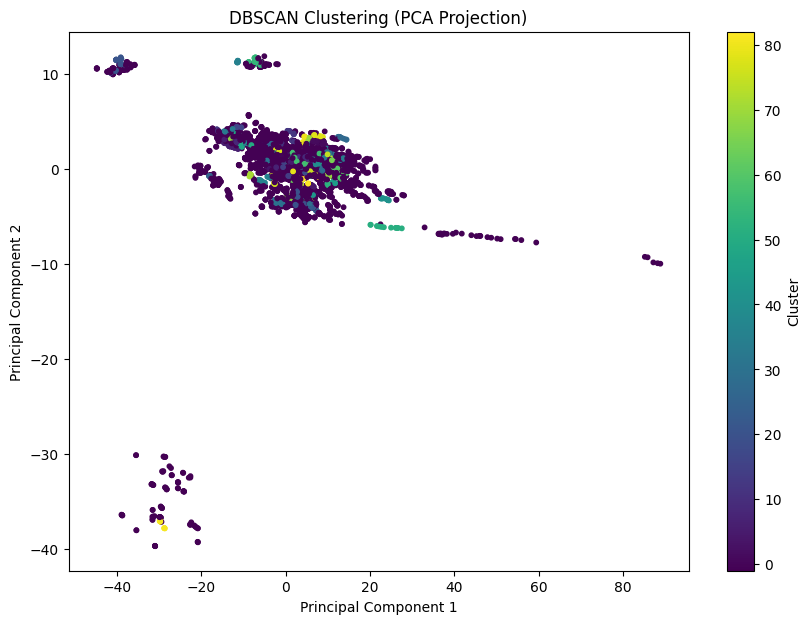

In [21]:
# 5. Shuffle + subset për DBSCAN
X_shuffled, y_shuffled = shuffle(
    X_scaled,
    y,
    random_state=42
)

X_dbscan = X_shuffled[:5000]
y_dbscan = y_shuffled[:5000]

# 6. DBSCAN me disa eps
for eps_value in [2, 3, 4, 5]:

    dbscan = DBSCAN(
        eps=eps_value,
        min_samples=10
    )

    clusters = dbscan.fit_predict(X_dbscan)

    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = np.sum(clusters == -1)

    print(f"eps={eps_value}")
    print("Clusters:", n_clusters)
    print("Noise:", n_noise)
    print("----------------")

# 7. Ruajmë një model final për vizualizim
dbscan_final = DBSCAN(
    eps=4,
    min_samples=10
)

clusters_dbscan = dbscan_final.fit_predict(X_dbscan)



eps=2
Clusters: 37
Noise: 4603
----------------
eps=3
Clusters: 54
Noise: 4398
----------------
eps=4
Clusters: 83
Noise: 3672
----------------
eps=5
Clusters: 87
Noise: 2217
----------------


Cluster -1: 3672
Cluster 0: 22
Cluster 1: 31
Cluster 2: 15
Cluster 3: 24
Cluster 4: 10
Cluster 5: 11
Cluster 6: 41
Cluster 7: 11
Cluster 8: 17
Cluster 9: 53
Cluster 10: 13
Cluster 11: 12
Cluster 12: 24
Cluster 13: 13
Cluster 14: 13
Cluster 15: 25
Cluster 16: 10
Cluster 17: 11
Cluster 18: 10
Cluster 19: 11
Cluster 20: 59
Cluster 21: 45
Cluster 22: 10
Cluster 23: 20
Cluster 24: 10
Cluster 25: 10
Cluster 26: 18
Cluster 27: 12
Cluster 28: 10
Cluster 29: 10
Cluster 30: 27
Cluster 31: 11
Cluster 32: 42
Cluster 33: 11
Cluster 34: 10
Cluster 35: 10
Cluster 36: 11
Cluster 37: 16
Cluster 38: 10
Cluster 39: 12
Cluster 40: 22
Cluster 41: 12
Cluster 42: 10
Cluster 43: 11
Cluster 44: 10
Cluster 45: 10
Cluster 46: 22
Cluster 47: 11
Cluster 48: 23
Cluster 49: 17
Cluster 50: 13
Cluster 51: 13
Cluster 52: 12
Cluster 53: 10
Cluster 54: 32
Cluster 55: 14
Cluster 56: 10
Cluster 57: 29
Cluster 58: 18
Cluster 59: 12
Cluster 60: 18
Cluster 61: 11
Cluster 62: 10
Cluster 63: 10
Cluster 64: 11
Cluster 65: 10
Clu

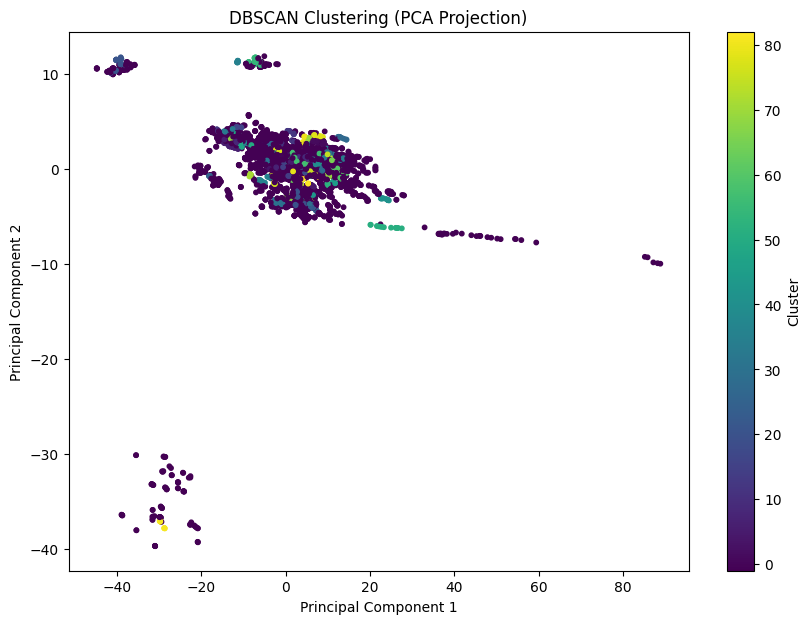

In [22]:

# 8. Shfaqim madhësinë e çdo clusteri
unique, counts = np.unique(clusters_dbscan, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count}")

# 9. PCA për vizualizim 2D
pca = PCA(n_components=2)
X_dbscan_pca = pca.fit_transform(X_dbscan)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_dbscan_pca[:, 0],
    X_dbscan_pca[:, 1],
    c=clusters_dbscan,
    cmap="viridis",
    s=10
)

plt.title("DBSCAN Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.utils import shuffle
from sklearn.metrics import silhouette_score
import numpy as np

X_shuffled, y_shuffled = shuffle(
    X_scaled,
    y,
    random_state=42
)

X_agg = X_shuffled[:5000]
y_agg = y_shuffled[:5000]

agg = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

clusters_agg = agg.fit_predict(X_agg)

unique, counts = np.unique(clusters_agg, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count}")

Cluster 0: 2729
Cluster 1: 104
Cluster 2: 2050
Cluster 3: 117


In [31]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

agg_results = []

for k in [2, 3, 4, 5, 6, 7, 8]:
    for linkage_method in ["ward", "complete", "average", "single"]:
        
        agg = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage_method
        )
        
        clusters = agg.fit_predict(X_agg)
        
        silhouette = silhouette_score(
            X_agg,
            clusters,
            sample_size=3000,
            random_state=42
        )
        
        unique, counts = np.unique(clusters, return_counts=True)
        cluster_distribution = dict(zip(unique, counts))
        
        agg_results.append([
            k,
            linkage_method,
            silhouette,
            cluster_distribution
        ])

agg_results_df = pd.DataFrame(
    agg_results,
    columns=["k", "linkage", "silhouette_score", "cluster_distribution"]
)

agg_results_df

,k,linkage,silhouette_score,cluster_distribution
0,2,ward,0.559197,"{0: 4779, 1: 221}"
1,2,complete,0.543264,"{0: 4969, 1: 31}"
2,2,average,0.602789,"{0: 4995, 1: 5}"
3,2,single,0.558506,"{0: 4896, 1: 104}"
4,3,ward,0.160730,"{0: 221, 1: 2729, 2: 2050}"
5,3,complete,0.518949,"{0: 4748, 1: 31, 2: 221}"
6,3,average,0.541752,"{0: 4964, 1: 5, 2: 31}"
7,3,single,0.555655,"{0: 4891, 1: 104, 2: 5}"
8,4,ward,0.182014,"{0: 2729, 1: 104, 2: 2050, 3: 117}"
9,4,complete,0.521115,"{0: 221, 1: 31, 2: 4743, 3: 5}"


In [32]:
agg_results_df.sort_values(
    by="silhouette_score",
    ascending=False
)

,k,linkage,silhouette_score,cluster_distribution
2,2,average,0.602789,"{0: 4995, 1: 5}"
11,4,single,0.561437,"{0: 4774, 1: 104, 2: 5, 3: 117}"
15,5,single,0.560551,"{0: 4769, 1: 104, 2: 5, 3: 117, 4: 5}"
0,2,ward,0.559197,"{0: 4779, 1: 221}"
3,2,single,0.558506,"{0: 4896, 1: 104}"
7,3,single,0.555655,"{0: 4891, 1: 104, 2: 5}"
1,2,complete,0.543264,"{0: 4969, 1: 31}"
6,3,average,0.541752,"{0: 4964, 1: 5, 2: 31}"
13,5,complete,0.528661,"{0: 31, 1: 104, 2: 4743, 3: 5, 4: 117}"
14,5,average,0.528661,"{0: 31, 1: 104, 2: 4743, 3: 5, 4: 117}"


In [33]:
#Vizualizimi
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_agg_pca = pca.fit_transform(X_agg)

print(X_agg_pca.shape)

(5000, 2)


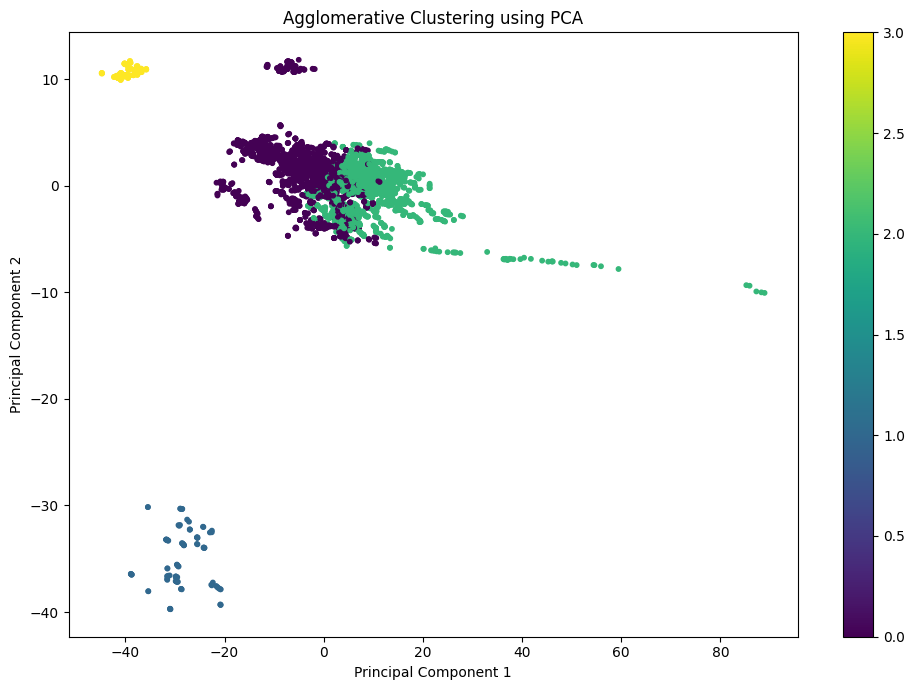

In [35]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_agg_pca[:,0],
    X_agg_pca[:,1],
    c=clusters_agg,
    cmap="viridis",
    s=10
)

plt.title("Agglomerative Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter)

plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)
import pandas as pd

ari_agg = adjusted_rand_score(
    y_agg,
    clusters_agg
)

nmi_agg = normalized_mutual_info_score(
    y_agg,
    clusters_agg
)

print(f"ARI: {ari_agg:.4f}")
print(f"NMI: {nmi_agg:.4f}")

comparison_agg = pd.crosstab(
    y_agg,
    clusters_agg,
    rownames=["True Label"],
    colnames=["Cluster"]
)

print(comparison_agg)

ARI: 0.0001
NMI: 0.0007
Cluster       0   1    2   3
True Label                  
0           692  32  491  29
1           682  27  536  25
2           719  21  562  29
3           636  24  461  34
